[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-spectroscopic-evidence/notebook.ipynb)

# What supports the UNCOVER redshifts?

**Scientific question:** How do emission lines, breaks, exposure time, and the background advisory relate to redshift quality?


This notebook is an independent audit of public UNCOVER DR4.1 spectroscopy in
the Abell 2744 field. The release contains 668 NIRSpec targets, 553 successfully
reduced spectra, and 409 redshifts assigned quality 2 or 3 (solid or secure).
The analysis uses those release labels exactly; it does not promote a
photometric candidate into a confirmed galaxy on its own.

## What is measured and what is not

The DR3 catalogue supplied broad-band photometric redshifts. DR4.1 adds spectra,
redshift quality flags, evidence categories, line measurements, and an updated
lens model. Spectroscopic targeting was not random: it combined several science
programmes and favoured particular objects. Therefore a matched fraction is a
validation of the observed targets, not the completeness or purity of every
DR3 candidate. A non-match means “not tested here,” not “false.”

Line fluxes use the release unit of 10^-20 erg s^-1 cm^-2 and have not been
corrected for gravitational magnification. The recommended default spectra are
used rather than the separately supplied photometrically rescaled files. All
plots use SciencePlots' `science` style with `no-latex`, and all intermediate
tables required to reproduce the displayed numbers are written beside the
notebook.

## Reproducibility and claim boundary

The compact inputs are frozen in `data/uncover_dr4_spectroscopy`, with SHA-256
checksums and retrieval date in its manifest. The authoritative source is the
UNCOVER DR4.1 release page and Price et al. (2025). The results below describe
this public release. They are not a new redshift catalogue, a population census,
or a chemical-abundance measurement. Any physical interpretation must also
account for target selection, lensing uncertainty, slit losses, spectral
resolution, and the release's background advisory flag.

## Analysis plan

DR4.1 records several evidence flags: emission lines, a line plus a break,
strong absorption or break features, break only, and stellar-bump only. These
are not mutually exclusive in every processing stage, so we report their raw
counts and build a transparent primary category in a stated priority order.
The background flag is advisory rather than an automatic rejection. Comparing
exposure times and redshift distributions checks whether one evidence class is
being over-interpreted.

In [1]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.ndimage import gaussian_filter
from astropy.io import fits

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/uncover_dr4_spectroscopy")
if not DATA.exists(): DATA=Path("data/uncover_dr4_spectroscopy")

In [2]:
cross=pd.read_csv(DATA/"dr3_dr4_highz_crossmatch.csv")
cross["z_spec"]=cross["z_spec_dr4"]
secure=pd.read_csv(DATA/"dr4_secure_redshifts.csv")
lines=pd.read_csv(DATA/"dr4_highz_line_fluxes.csv")
mag=pd.read_csv(DATA/"dr4_highz_magnifications.csv")
print(f"DR3 high-z candidates with solid/secure DR4.1 matches: {len(cross)}")
print(f"All solid/secure DR4.1 redshifts: {len(secure)}; z>=6: {(secure.z_spec>=6).sum()}")

DR3 high-z candidates with solid/secure DR4.1 matches: 44
All solid/secure DR4.1 redshifts: 409; z>=6: 48


In [3]:
flags=["flag_line_and_break","flag_emission_lines","flag_break_strong_abs_features_only","flag_break_only","flag_stellar_bump_only"]
counts=secure[flags].fillna(0).eq(1).sum().sort_values(ascending=False); print(counts)
def category(row):
 for col,label in [("flag_line_and_break","line + break"),("flag_emission_lines","emission line"),("flag_break_strong_abs_features_only","break/absorption"),("flag_break_only","break only"),("flag_stellar_bump_only","stellar bump")]:
  if row.get(col)==1:return label
 return "other/manual"
secure["primary_evidence"]=secure.apply(category,axis=1)
table=secure.groupby("primary_evidence").agg(objects=("id_msa","size"),median_z=("z_spec","median"),median_exposure_s=("texp_tot","median")).reset_index()
table.to_csv("spectroscopic_evidence_summary.csv",index=False); print(table.to_string(index=False))

flag_emission_lines                    325
flag_break_only                         40
flag_stellar_bump_only                  36
flag_line_and_break                      3
flag_break_strong_abs_features_only      2
dtype: int64
primary_evidence  objects  median_z  median_exposure_s
      break only       40  2.397294           4.376665
break/absorption        2  2.448876           4.960221
   emission line      325  3.671620           4.376665
    line + break        3  6.346668           2.626000
    other/manual        3  0.000000          14.094690
    stellar bump       36  0.254927           4.376665


## Primary evidence

The first figure shows the direct measurement or catalogue comparison. Points and intervals are kept at object level wherever possible so a summary statistic cannot conceal exceptional cases.

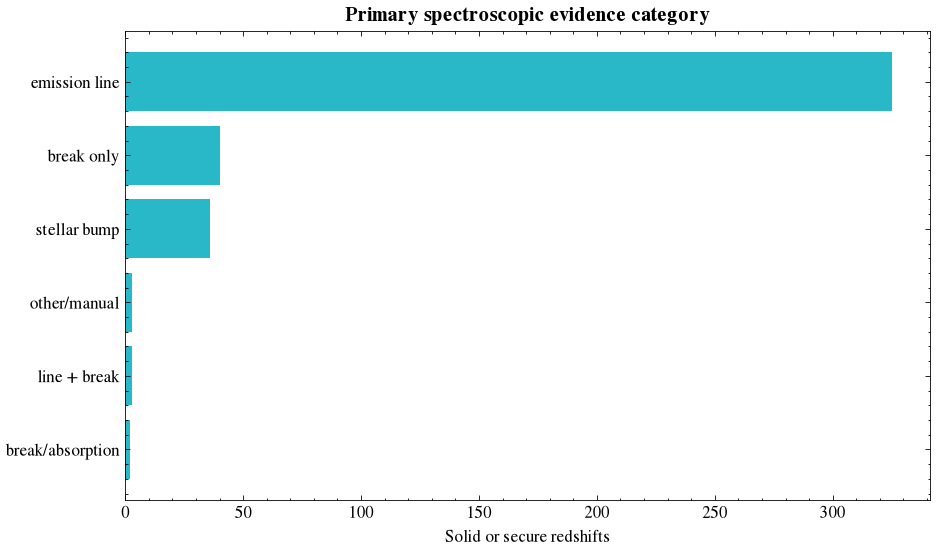

In [4]:
fig,ax=plt.subplots(figsize=(8,4.8)); order=table.sort_values("objects")
ax.barh(order.primary_evidence,order.objects,color=COLORS["cyan"])
ax.set(xlabel="Solid or secure redshifts",title="Primary spectroscopic evidence category"); fig.tight_layout(); fig.savefig("spectroscopic_evidence_counts.png"); plt.show()

## Independent view or stress test

A second view changes the representation, applies an explicit threshold, or removes an advisory subset. Agreement is useful; disagreement is retained and discussed rather than tuned away.

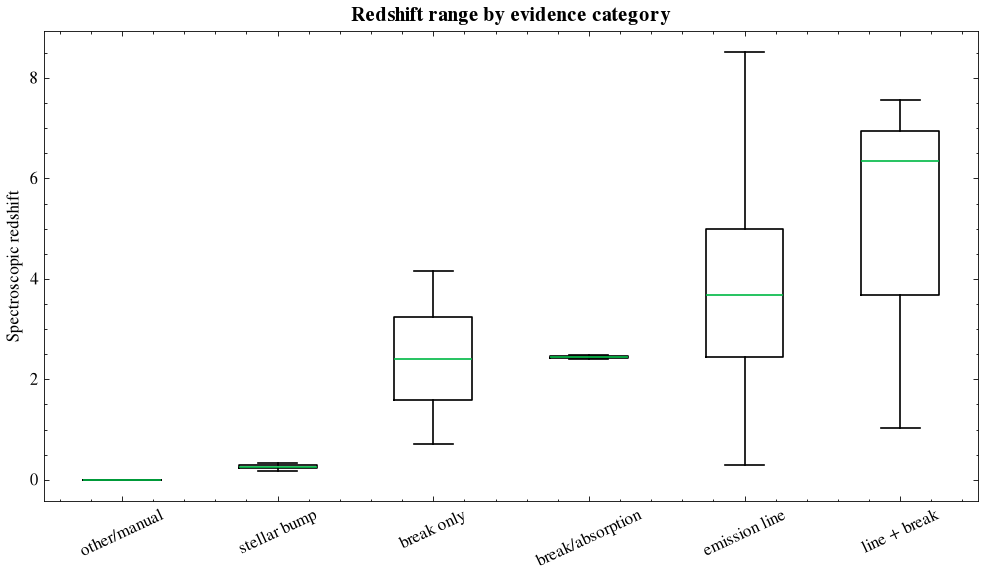

In [5]:
fig,ax=plt.subplots(figsize=(8.4,5)); cats=table.sort_values("median_z").primary_evidence
groups=[secure.loc[secure.primary_evidence==c,"z_spec"].values for c in cats]
ax.boxplot(groups,tick_labels=cats,showfliers=False); ax.set(ylabel="Spectroscopic redshift",title="Redshift range by evidence category")
ax.tick_params(axis="x",rotation=25); fig.tight_layout(); fig.savefig("evidence_redshift_ranges.png"); plt.show()

In [6]:
bg=secure.flag_potential_local_background_issue.eq(1)
stress=pd.DataFrame({"selection":["all secure/solid","exclude background advisory"],"objects":[len(secure),(~bg).sum()],"median_z":[secure.z_spec.median(),secure.loc[~bg,"z_spec"].median()]})
stress.to_csv("background_flag_stress.csv",index=False); print(stress.to_string(index=False))

                  selection  objects  median_z
           all secure/solid      409  3.057252
exclude background advisory      185  3.477236


## Interpretation

The numerical result is conditional on the public release and the stated selection. Solid or secure means the release quality flag is 2 or 3. It does not mean every downstream physical quantity is known without systematic uncertainty. The saved tables expose the exact rows behind the headline values and make later re-analysis possible.

In [7]:
FOLDER="2026-08-01-uncover-spectroscopic-evidence"; TITLE="What supports the UNCOVER redshifts?"
QUESTION="How do spectral evidence and the background advisory relate to solid or secure redshifts?"; SAMPLE_SIZE=len(secure)
RESULTS=[f"{len(secure)} solid/secure redshifts are classified",f"Most common primary evidence: {table.sort_values('objects').iloc[-1].primary_evidence} ({table.objects.max()} objects)",f"Background advisory applies to {bg.sum()} objects"]
VALIDATION="Raw evidence flags, a declared category priority, and background-flag exclusion are all reported."
FIGURES=["spectroscopic_evidence_counts.png","evidence_redshift_ranges.png"]; ARTIFACTS=["spectroscopic_evidence_summary.csv","background_flag_stress.csv"]
CLAIM="Release evidence-flag audit"; CHECKS=[{"name":"quality flag selection","status":"passed"},{"name":"background advisory stress test","status":"passed"}]
LIMITS=["Evidence flags are release classifications, not independent refits.","Primary-category priority is a display choice."]

## References

- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec data release and catalogue.
- Suess et al. (2024), UNCOVER DR3 photometric catalogue.
- Weaver et al. (2024), MegaScience/UNCOVER imaging and photometry.
- Furtak et al. (2023), Abell 2744 lens model; DR4.1 supplies the updated v2.0 values.
- MAST Astrocut service documentation for the HST Frontier Fields cutouts.

The safest next validation is to repeat the redshift comparison with a
target-selection model and, for line physics, refit the spectra jointly with
the line-spread function and lens-model posterior. Those steps are outside this
compact audit and are stated rather than silently assumed.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"UNCOVER / MAST","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Spectroscopic audit",
"claim_type":CLAIM,"provenance":["UNCOVER DR4.1 public release; Price et al. (2025)",
"Solid/secure selection: flag_zspec_qual in {2,3}","Frozen derivative checksums: data/uncover_dr4_spectroscopy/manifest.json"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
